# External Validation Figure

Rebuilds the rally-structure figure from files on disk. **No GPU, no pipeline
run**, so the styling can be iterated on freely.

Reads:

```
raw/external/{VIDEO}_gt.txt                    annotation
derived/analysed/{VIDEO}/shots.parquet         predictions
outputs/metrics/external_{VIDEO}.json          metrics
outputs/metrics/external_{VIDEO}_pairs.csv     matched pairs
```

Section 3 draws three layouts. Pick one, or take pieces from each. Every knob
that affects appearance is in section 2.

Sized for an IEEE double-column figure (7.16 in). Section 5 writes PDF and PNG.


## 1. Load

In [1]:
BASE  = "/content/drive/MyDrive/tt_coach"
VIDEO = "test_match2"
RALLY_GAP = 1.5          # same rule the pipeline uses

from google.colab import drive
drive.mount('/content/drive')

import json, re
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

BASE = Path(BASE)
M    = BASE/"outputs/metrics"
FIGS = BASE/"outputs/figures"; FIGS.mkdir(parents=True, exist_ok=True)
CLASSES = ["serve", "attack", "control", "defence"]

# --- annotation --------------------------------------------------------------
NAME = {"service":"serve","serve":"serve","attack":"attack",
        "control":"control","defense":"defence","defence":"defence"}
pat = re.compile(r"(\d+):(\d+\.?\d*)\s*-\s*player\s*\((left|right)\)\s*-\s*(\w+)", re.I)
gt = []
for line in (BASE/f"raw/external/{VIDEO}_gt.txt").read_text().splitlines():
    if (m := pat.search(line)):
        mm, ss, side, cls = m.groups()
        gt.append(dict(t=int(mm)*60+float(ss), player=side.lower(),
                       shot_class=NAME[cls.lower()]))
gt = pd.DataFrame(gt).sort_values("t").reset_index(drop=True)
gt["rally"] = (gt.t.diff().fillna(0) > RALLY_GAP).cumsum()

# --- predictions -------------------------------------------------------------
pred = pd.read_parquet(BASE/f"derived/analysed/{VIDEO}/shots.parquet")
pred = pred.sort_values("timestamp_s").reset_index(drop=True)

# --- metrics and pairs -------------------------------------------------------
summ  = json.loads((M/f"external_{VIDEO}.json").read_text())
pairs = pd.read_csv(M/f"external_{VIDEO}_pairs.csv")

# which shots matched, which did not
gt["matched"]   = gt.t.isin(pairs.gt_t)
pred["matched"] = pred.timestamp_s.round(6).isin(pairs.pred_t.round(6))

print(f"annotated  {len(gt)} shots, {gt.rally.nunique()} rallies")
print(f"detected   {len(pred)} shots, {pred.rally_id.nunique()} rallies")
print(f"matched    {len(pairs)}  |  unmatched annotations "
      f"{(~gt.matched).sum()}  |  unmatched predictions {(~pred.matched).sum()}")
print(f"\ndetection F1 {summ['detection']['f1']:.3f} at "
      f"+/-{summ['detection']['tolerance_s']*1000:.0f} ms")
print(f"timing offset {summ['detection']['offset_mean_ms']:+.1f} +/- "
      f"{summ['detection']['offset_sd_ms']:.1f} ms")

if (~gt.matched).any():
    print(f"\nunmatched annotation times: {gt[~gt.matched].t.tolist()}")
if (~pred.matched).any():
    print(f"unmatched prediction times: "
          f"{pred[~pred.matched].timestamp_s.round(2).tolist()}")

Mounted at /content/drive
annotated  35 shots, 8 rallies
detected   35 shots, 8 rallies
matched    34  |  unmatched annotations 1  |  unmatched predictions 1

detection F1 0.971 at +/-67 ms
timing offset +0.9 +/- 3.8 ms

unmatched annotation times: [13.91]
unmatched prediction times: [22.18]


## 2. Style

Everything that affects appearance lives here.

In [2]:
# --- size ---------------------------------------------------------------------
FIG_W   = 7.16        # IEEE double column, inches. 3.5 for single column.
FIG_H   = 2.2

# --- type ---------------------------------------------------------------------
FS_BASE  = 8          # axis labels, ticks
FS_TITLE = 9
FS_SMALL = 7          # legend, annotations
FONT     = "DejaVu Sans"    # "Times New Roman" to match an IEEE body font

# --- colour -------------------------------------------------------------------
PAL = {"serve":   "#1d4ed8",
       "attack":  "#b91c1c",
       "control": "#065f46",
       "defence": "#854d0e"}
C_GT   = "#5a5350"    # annotated rally bars
C_PRED = "#f55f02"    # detected rally bars
C_MISS = "#e03131"    # unmatched shots

# --- geometry -----------------------------------------------------------------
BAR_H     = 7         # rally bar thickness
DOT_S     = 18        # shot marker size
DOT_OFF   = 0.20      # vertical offset of shots from their bar
BAR_ALPHA = 0.55

# --- markers, so the figure survives greyscale printing -----------------------
MARKER = {"serve": "o", "attack": "^", "control": "s", "defence": "D"}

mpl.rcParams.update({
    "figure.dpi": 140, "savefig.dpi": 400,
    "font.family": FONT, "font.size": FS_BASE,
    "axes.titlesize": FS_TITLE, "axes.labelsize": FS_BASE,
    "xtick.labelsize": FS_BASE, "ytick.labelsize": FS_BASE,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.grid": True, "grid.alpha": 0.20, "grid.linewidth": 0.5,
    "legend.frameon": False, "legend.fontsize": FS_SMALL,
    "figure.constrained_layout.use": True,
})

def class_legend(ax, loc="upper right", ncol=4, include_miss=False):
    h = [Line2D([], [], marker=MARKER[c], color="none", markerfacecolor=PAL[c],
                markeredgecolor="none", markersize=4.5, label=c)
         for c in CLASSES]
    if include_miss:
        h.append(Line2D([], [], marker="x", color=C_MISS, lw=0,
                        markersize=5, markeredgewidth=1.4, label="unmatched"))
    ax.legend(handles=h, loc=loc, ncol=ncol, handletextpad=0.3,
              columnspacing=1.0, borderaxespad=0.2)

def draw_shots(ax, times, classes, y, matched=None, size=DOT_S):
    for c in CLASSES:
        m = np.array([cc == c for cc in classes])
        if m.any():
            ax.scatter(np.asarray(times)[m], np.full(m.sum(), y),
                       s=size, marker=MARKER[c], c=PAL[c],
                       linewidths=0, zorder=3)
    if matched is not None:
        u = ~np.asarray(matched)
        if u.any():
            ax.scatter(np.asarray(times)[u], np.full(u.sum(), y),
                       s=size*2.4, marker="x", c=C_MISS,
                       linewidths=1.3, zorder=4)

print("style set")

style set


## 3. Layouts

### A. Two tracks

Closest to what you have. Annotated above, detected below, rally extents as
bars, shots as markers.

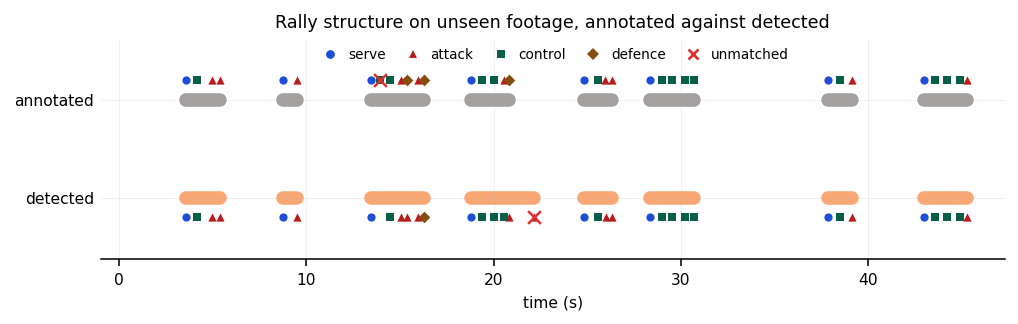

In [3]:
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))

for r in gt.rally.unique():
    g = gt[gt.rally == r]
    ax.plot([g.t.min(), g.t.max()], [1, 1], lw=BAR_H, solid_capstyle="round",
            color=C_GT, alpha=BAR_ALPHA, zorder=1)
for r in pred.rally_id.unique():
    g = pred[pred.rally_id == r]
    ax.plot([g.timestamp_s.min(), g.timestamp_s.max()], [0, 0], lw=BAR_H,
            solid_capstyle="round", color=C_PRED, alpha=BAR_ALPHA, zorder=1)

draw_shots(ax, gt.t.values, gt.shot_class.values, 1 + DOT_OFF,
           matched=gt.matched.values)
draw_shots(ax, pred.timestamp_s.values, pred.shot_class.values, -DOT_OFF,
           matched=pred.matched.values)

ax.set_yticks([0, 1]); ax.set_yticklabels(["detected", "annotated"])
ax.set_xlabel("time (s)"); ax.set_ylim(-0.62, 1.62)
ax.set_xlim(-1, gt.t.max() + 2)
ax.tick_params(axis="y", length=0)
class_legend(ax, loc="upper center", ncol=5, include_miss=True)
ax.set_title("Rally structure on unseen footage, annotated against detected")
plt.show()

### B. Two tracks with match lines

Adds a thin line between each matched pair. Makes the correspondence explicit
rather than implied by proximity, which matters because the previous version of
this evaluation produced matches that only *looked* aligned.

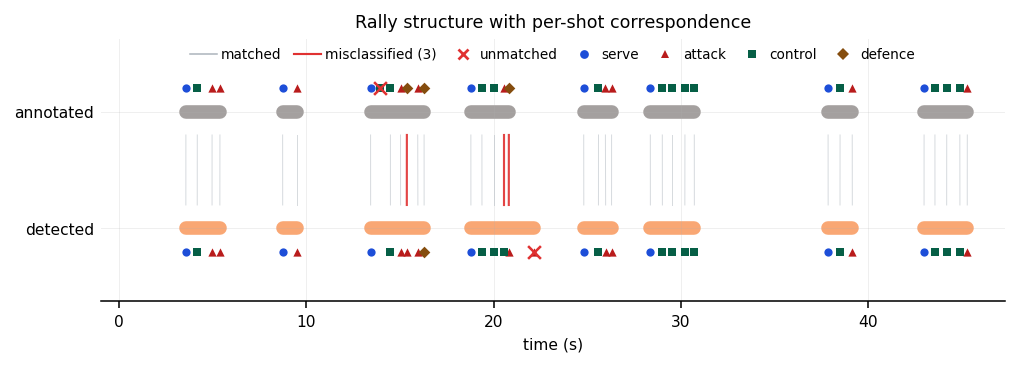

In [4]:
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H + 0.3))

for _, p in pairs.iterrows():
    ok = p.gt_class == p.pred_class
    ax.plot([p.gt_t, p.pred_t], [1 - DOT_OFF, DOT_OFF],
            lw=0.5 if ok else 1.1,
            color="#adb5bd" if ok else C_MISS,
            alpha=0.5 if ok else 0.9, zorder=2)

for r in gt.rally.unique():
    g = gt[gt.rally == r]
    ax.plot([g.t.min(), g.t.max()], [1, 1], lw=BAR_H, solid_capstyle="round",
            color=C_GT, alpha=BAR_ALPHA, zorder=1)
for r in pred.rally_id.unique():
    g = pred[pred.rally_id == r]
    ax.plot([g.timestamp_s.min(), g.timestamp_s.max()], [0, 0], lw=BAR_H,
            solid_capstyle="round", color=C_PRED, alpha=BAR_ALPHA, zorder=1)

draw_shots(ax, gt.t.values, gt.shot_class.values, 1 + DOT_OFF,
           matched=gt.matched.values)
draw_shots(ax, pred.timestamp_s.values, pred.shot_class.values, -DOT_OFF,
           matched=pred.matched.values)

n_wrong = int((pairs.gt_class != pairs.pred_class).sum())
ax.set_yticks([0, 1]); ax.set_yticklabels(["detected", "annotated"])
ax.set_xlabel("time (s)"); ax.set_ylim(-0.62, 1.62)
ax.set_xlim(-1, gt.t.max() + 2)
ax.tick_params(axis="y", length=0)

h = [Line2D([], [], color="#adb5bd", lw=0.8, label="matched"),
     Line2D([], [], color=C_MISS, lw=1.1, label=f"misclassified ({n_wrong})"),
     Line2D([], [], marker="x", color=C_MISS, lw=0, markersize=5,
            markeredgewidth=1.4, label="unmatched")]
h += [Line2D([], [], marker=MARKER[c], color="none", markerfacecolor=PAL[c],
             markeredgecolor="none", markersize=4.5, label=c) for c in CLASSES]
ax.legend(handles=h, loc="upper center", ncol=7, handletextpad=0.3,
          columnspacing=0.9, borderaxespad=0.2)
ax.set_title("Rally structure with per-shot correspondence")
plt.show()

### C. Rally bands

Rallies as shaded vertical regions, shots as ticks above and below one axis.
Denser, and the 8-for-8 agreement is the first thing the eye picks up.

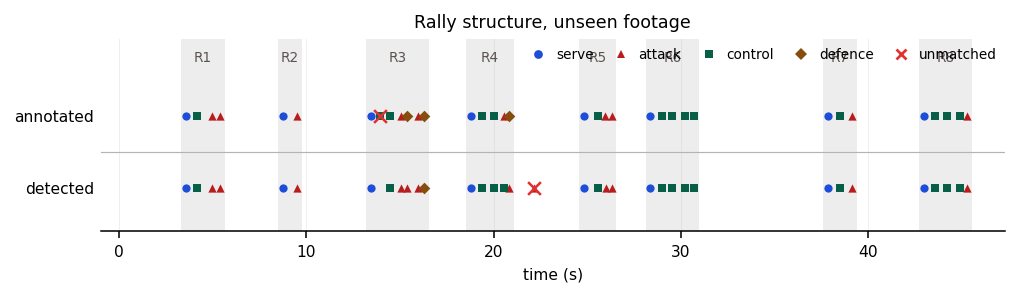

In [5]:
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H - 0.2))

for i, r in enumerate(sorted(gt.rally.unique())):
    g = gt[gt.rally == r]
    ax.axvspan(g.t.min() - 0.25, g.t.max() + 0.25, color=C_GT, alpha=0.10,
               lw=0, zorder=0)
    ax.text((g.t.min() + g.t.max())/2, 0.80, f"R{i+1}", ha="center",
            fontsize=FS_SMALL, color="#5a5350")

draw_shots(ax, gt.t.values, gt.shot_class.values, 0.32,
           matched=gt.matched.values, size=DOT_S)
draw_shots(ax, pred.timestamp_s.values, pred.shot_class.values, -0.32,
           matched=pred.matched.values, size=DOT_S)
ax.axhline(0, color="#adb5bd", lw=0.6, zorder=1)

ax.set_yticks([-0.32, 0.32]); ax.set_yticklabels(["detected", "annotated"])
ax.set_xlabel("time (s)"); ax.set_ylim(-0.7, 1.0)
ax.set_xlim(-1, gt.t.max() + 2)
ax.tick_params(axis="y", length=0)
ax.grid(axis="y", visible=False)
class_legend(ax, loc="upper right", ncol=5, include_miss=True)
ax.set_title("Rally structure, unseen footage")
plt.show()

## 4. Timing detail (optional inset)

The offsets are tight enough that this could sit alongside the main figure:
mean under 1 ms, standard deviation under a quarter of a source frame.

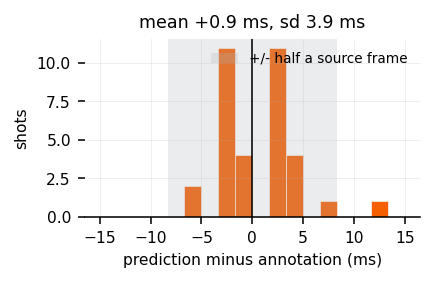

one source frame at 60 fps = 16.7 ms
sd is 0.23 of a source frame
largest |offset| 11.7 ms, tolerance was 67 ms


In [6]:
src_fps = summ["source"]["fps"]
frame_ms = 1000/src_fps

fig, ax = plt.subplots(figsize=(FIG_W/2.4, FIG_H - 0.3))
ax.hist(pairs.offset_ms, bins=np.arange(-15, 16, 1.667), color=C_PRED,
        edgecolor="white", linewidth=0.3)
ax.axvline(0, color="black", lw=0.8)
ax.axvspan(-frame_ms/2, frame_ms/2, color="#adb5bd", alpha=0.25, lw=0,
           label=f"+/- half a source frame")
ax.set_xlabel("prediction minus annotation (ms)")
ax.set_ylabel("shots")
ax.set_title(f"mean {pairs.offset_ms.mean():+.1f} ms, "
             f"sd {pairs.offset_ms.std():.1f} ms")
ax.legend(loc="upper right")
plt.show()

print(f"one source frame at {src_fps:.0f} fps = {frame_ms:.1f} ms")
print(f"sd is {pairs.offset_ms.std()/frame_ms:.2f} of a source frame")
print(f"largest |offset| {pairs.offset_ms.abs().max():.1f} ms, "
      f"tolerance was {summ['detection']['tolerance_s']*1000:.0f} ms")

## 5. Save

Draws layout B again and writes it out. Swap in the body of A or C if you
prefer one of those.

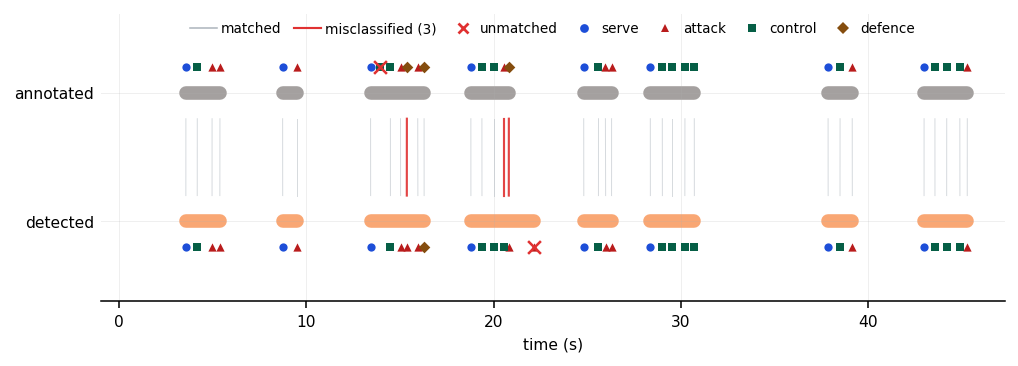

saved to /content/drive/MyDrive/tt_coach/outputs/figures/external_rally_structure.{pdf,png}


In [7]:
# direct version: redraw layout B and save in one go
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H + 0.3))

for _, p in pairs.iterrows():
    ok = p.gt_class == p.pred_class
    ax.plot([p.gt_t, p.pred_t], [1 - DOT_OFF, DOT_OFF],
            lw=0.5 if ok else 1.1,
            color="#adb5bd" if ok else C_MISS,
            alpha=0.5 if ok else 0.9, zorder=2)
for r in gt.rally.unique():
    g = gt[gt.rally == r]
    ax.plot([g.t.min(), g.t.max()], [1, 1], lw=BAR_H, solid_capstyle="round",
            color=C_GT, alpha=BAR_ALPHA, zorder=1)
for r in pred.rally_id.unique():
    g = pred[pred.rally_id == r]
    ax.plot([g.timestamp_s.min(), g.timestamp_s.max()], [0, 0], lw=BAR_H,
            solid_capstyle="round", color=C_PRED, alpha=BAR_ALPHA, zorder=1)
draw_shots(ax, gt.t.values, gt.shot_class.values, 1 + DOT_OFF,
           matched=gt.matched.values)
draw_shots(ax, pred.timestamp_s.values, pred.shot_class.values, -DOT_OFF,
           matched=pred.matched.values)

n_wrong = int((pairs.gt_class != pairs.pred_class).sum())
ax.set_yticks([0, 1]); ax.set_yticklabels(["detected", "annotated"])
ax.set_xlabel("time (s)"); ax.set_ylim(-0.62, 1.62)
ax.set_xlim(-1, gt.t.max() + 2); ax.tick_params(axis="y", length=0)
h = [Line2D([], [], color="#adb5bd", lw=0.8, label="matched"),
     Line2D([], [], color=C_MISS, lw=1.1, label=f"misclassified ({n_wrong})"),
     Line2D([], [], marker="x", color=C_MISS, lw=0, markersize=5,
            markeredgewidth=1.4, label="unmatched")]
h += [Line2D([], [], marker=MARKER[c], color="none", markerfacecolor=PAL[c],
             markeredgecolor="none", markersize=4.5, label=c) for c in CLASSES]
ax.legend(handles=h, loc="upper center", ncol=7, handletextpad=0.3,
          columnspacing=0.9, borderaxespad=0.2)

for ext in ("pdf", "png"):
    plt.savefig(FIGS/f"external_rally_structure.{ext}", bbox_inches="tight",
                facecolor="white")
plt.show()
print(f"saved to {FIGS}/external_rally_structure.{{pdf,png}}")

---
## Notes

**Markers as well as colour.** Circle, triangle, square and diamond, so the
four classes survive greyscale printing.

**Unmatched shots carry a red cross.** One annotation and one prediction did
not pair within the tolerance. Marking them is more honest than a figure
implying every shot lined up, and it costs nothing.

**Font.** `FONT = "Times New Roman"` in section 2 matches an IEEE body font, if
it is installed. Colab usually only has DejaVu, so set it locally if it
matters.

**Width.** 7.16 in spans two IEEE columns. 3.5 for a single column, in which
case drop `FIG_H` and the legend to two rows.
